# Numerical experiments "Towards Model-Agnostic Federated Learning over Networks" IV Analyses of Algorithm 2 for Local Linear Models

In [1]:
from joblib import Parallel, delayed
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import random
import scipy
from sklearn.tree import DecisionTreeRegressor
from sklearn.utils import resample
import torch

# plt settings
plt.rcParams.update({'axes.spines.right': False,
                     'axes.spines.top': False})
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['axes.titlesize'] = 16

## Clustered synthetic dataset

Experiments are performed on a synthetic dataset whose empirical graph $\mathcal {G}$ consists of one cluster $\mathcal{C}$, with $|\mathcal{C}|=50$. We denote the cluster assignment of node $i \in \mathcal{V}$ by ${c}^{(i)} \in \{0,1,2\}$. 

Each node $i \in \mathcal {V}$ of the empirical graph $\mathcal {G}$ holds a local dataset $\mathcal {D}^{(i)}$ of the form $\mathcal {D}^{(i)} := \{ (\mathbf{x}^{(i,1)}, {y}^{(i,1)}), ..., (\mathbf{x}^{(i,{m}_{i})}, {y}^{(i,{m}_{i})}) \}$. Thus, dataset $\mathcal {D}^{(i)}$ consist of ${m}_{i}$ data points, each characterized by a feature vector $\mathbf{x}^{(i,r)} \in \mathbb{R}^{d}$ and scalar label ${y}^{(i,r)}$, for $r=1,...,{m}_{i}$. The feature vectors $\mathbf{x}^{(i,r)} \sim \mathcal{N}(\mathbf{0},\mathbf{I}_{d})$, are drawn i.i.d. from a standard multivariate normal distribution. 

The labels of the data points are generated by a noisy linear model
\begin{equation}
{y}^{(i,r)} = (\mathbf{w}^{(i)})^T\mathbf{x}^{(i,r)} + {\varepsilon}^{(i,r)}
\end{equation}

The noise ${\varepsilon}^{(i,r)} \sim \mathcal{N}(0, {\sigma}^{2})$, for $i \in \mathcal{V}$ and $r=1,..,{m}_{i}$, are i.i.d. realizations of a normal distribution. The true underlying vector $\mathbf{w}^{(i)} \sim \mathcal{N}(0,1)$ is drawn from a standard normal distribution and is the same for nodes from the same cluster, i.e. $\mathbf{w}^{(i)}=\mathbf{w}^{({i}^{'})}$ if ${c}^{(i)}={c}^{({i}^{'})}$.

In addition to the local training dataset of size $m_i$, we generate validation subset with ${m}^{(val)}_{i}=100$ datapoints from the same distribution.

Dataset $\mathcal{P}^{(i)}$ is unlabeled dataset with feature vectors drawn i.i.d. from a standard normal distribution $\mathbf{x}^{(i,r)} \sim \mathcal{N}(\mathbf{0},\mathbf{I}_{d})$. The size of the dataset is $m_i^{(\mathcal{P})}=100$. This shared public dataset can be the same on all nodes or different for each node.

In [2]:
def get_data(n_clusters, n_ds, n_samples, n_features, noise_scale=1.0):
    
    """
    
    Function to create noisy Gaussian regression datasets. 
    Datasets within the cluster share the same true weight vector. 
    For each node we create training (size = n_samples) and validation (size = 100) ds.
    
    :param n_clusters:   number of clusters
    :param n_ds:         number of local datasets per cluster 
    :param n_samples:    number of samples in a local dataset
    :param n_features:   number of features of a datapoint
    :param noise_scale:  scale of normal distribution used to generate data noise
    
    :out ds_train:       list of (n_clusters*n_ds) local train datasets of sample size n_samples
    :out ds_val:         list of (n_clusters*n_ds) local validation datasets of sample size 100
    :out cluster_labels: list of (n_clusters*n_ds) cluster assignments for each local dataset 
    :out true_weights:   array of shape (n_clusters, n_features), true weight vector for each cluster

    """
    
    # Lists to store and return outputs
    ds_train       = []
    cluster_labels = []
    true_weights   = np.zeros((n_clusters, n_features))
    noise_norm     = np.zeros((n_clusters))
    
    for i in range(n_clusters):
        
        # Sample true weight vector for cluster i
        w = np.random.normal(0, 1, size=(n_features,1))
        true_weights[i] = w.reshape(-1,)

        noise_norm_ = 0
        for j in range(n_ds):
            # Sample datapoints from multivar Gaussian ~N(0,I)
            X = np.random.normal(0, 1.0, size=(n_samples, n_features))
            
            # Sample noise 
            noise = np.random.normal(loc=0.0, scale=noise_scale, size=(n_samples, 1))
            noise_norm_ = noise_norm_ + np.mean(noise**2)
            
            # Noisy Gaussian regression
            y = X@w + noise
            
            ds_train.append( (X, y) )
            cluster_labels.append(i)
        noise_norm[i] = noise_norm_

    return ds_train, cluster_labels, true_weights, noise_norm

In [3]:
def get_data_gauss(n_nodes, m_pub, n_features):

    """

    Create Gaussian dataset for all nodes.

    Args:
    : n_nodes    : scalar, number of nodes
    : m_pub      : scalar, number of samples in shared public dataset
    : n_features : scalar, number of features of a datapoint
    Out:
    : data_test  : array of shape (n_nodes, m_pub, n_features), feature matrix

    """

    ds_pub = np.random.normal(0, 1.0, size=(n_nodes, m_pub, n_features))

    return ds_pub

## Graph

In [4]:
def build_graph(ds_train, models, cluster_labels):

    """

    Function to generate graph.

    :param ds_train:       list of (n_clusters*n_ds) local train datasets of sample size n_samples (see function `get_data()`)
    :param models:         list of (n_clusters*n_ds) local models
    :param cluster_labels: list of (n_clusters*n_ds) cluster assignments for each local dataset 

    :out G:                list of (n_clusters*n_ds) python dictionaries (graph nodes) where each dict (node)  contain local train/ val datasets, model and shared test dataset

    """
    G = []
    for ds_t, model, c in zip(ds_train, models, cluster_labels):
        G.append({"ds_train": ds_t, "model": model, "cluster_label": c}) 
        
    return G

In [5]:
def build_edges(G, cluster_labels, p_in = 0.8, p_out = 0.2):

    """

    Create network edges (links) with Bernoulli distribution P(n) = p^n(1-p)^(1-n), where n={0,1}.
    Probability p_in for nodes within a cluster and probability p_out for nodes from different clusters.
    Edge weights are the same for all edges A_ij = 1; for A_ii = 0

    :param G:              list of (n_clusters*n_ds) python dictionaries (graph nodes) where each dict (node)  contain local train/ val datasets, model and shared dataset
    :param cluster_labels: list of (n_clusters*n_ds) cluster assignments for each local dataset 
    :param p_in:           probability of a link between nodes belonging to the same cluster 
    :param p_out:          probability of a link between nodes belonging to different clusters 

    :out A:                numpy array of shape (n_nodes, n_nodes), adjacency matrix of the graph, created with Bernoulli distribution and probabilities p_in and p_out.

    """
    
    nn = len(G)
    A = np.zeros((nn, nn))
    rows, cols = A.shape

    for i in range(rows):
        for j in range(cols):
            if i==j:
                A[i,j] = 0
            elif cluster_labels[i] == cluster_labels[j]:
                A[i,j] = np.random.binomial(n=1, p=p_in, size=5)[0] 
            else:
                A[i,j] = np.random.binomial(n=1, p=p_out, size=5)[0]

    # Create a symmetric matrix           
    A = np.tril(A) 
    A = A + A.T
    return A

In [6]:
def concat(ds):

    """

    Function to pool data for G_pooled.

    """
    Xs = []
    ys = []
    for X, y in ds:
        Xs.append(X)
        ys.append(y)
    return np.concatenate(Xs), np.concatenate(ys)  

In [7]:
def compute_bound(A, reg_term, noise_norm, n_clusters, n_ds):
    # Compute second smallest eigenvalue of Laplacian (of induced subgraph) and cluster boundary
    eigenvals = []
    cluster_bounds = []

    for i in range(n_clusters):
            # Induced subgraph == cluster
            subG = A[i*n_ds:i*n_ds+n_ds, i*n_ds:i*n_ds+n_ds]
            # The rest of the graph
            before_subG = A[i*n_ds:i*n_ds+n_ds, :i*n_ds]
            after_subG = A[i*n_ds:i*n_ds+n_ds, i*n_ds+n_ds:]
            # Sum all edges to other clusters
            out_edges = np.sum(before_subG) + np.sum(after_subG)
            cluster_bounds.append(out_edges)
            
            # Laplacian of induced subgraph
            D = np.diag(np.sum(subG, axis=1))
            eigenvalues = scipy.linalg.eigh(D-subG, eigvals_only=True)
            eigenvals.append(np.sort(eigenvalues)[1])
    bound = noise_norm / (reg_term*eigenvals[0])
    return bound

## Training loop

In [8]:
def train(G, A, ds_pub, true_weights, iters=1000, reg=0.01, parametric=False): 
    
    """
    Args:
    
    : G              : list of dicts [dict keys are: model, ds_train, ds_val, ds_shared, cluster_label], 
                       represents graph with n_nodes
    : A              : array, adjacency matrix
    : ds_pub         : array of size (n_nodes, m_pub, n_features), shared public dataset
    : true_weights   : array of size (n_clusters, n_features), true weight vector used in data generation
    : iters          : scalar, number of iterations or updates of the local model
    : reg            : scalar, scaling factor \alpha in GTV term
    : parametric     : boolean, indicates if MSE for weight vectors should be computed

    Out:

    : est_error      : array of size (n_nodes, iters), MSE for weight vectors should be computed
    
    """
    
    n_nodes      = len(G)                             # number of nodes in a graph
    m_pub        = ds_pub.shape[1]                    # sample size of the shared public ds
    nodes_preds  = np.zeros((n_nodes, m_pub))         # init predictions on a shared public ds

    # variation|| w^(i) - cluster_aver ||^2
    w_tilde      = np.zeros((iters))
    err          = np.zeros((n_nodes, iters))

    # Training loop
    for i in range(iters):
        w_hat = np.zeros((n_nodes, n_features))
        for n in range(n_nodes):
            # get node's data
            ds_train  = G[n]["ds_train"]
            model     = G[n]["model"]
            c         = G[n]["cluster_label"]
            w = true_weights[c]
            # current parameter vector
            w_hat_n   = model.get_params().reshape(-1,)
            w_hat[n]  = w_hat_n
            err[n,i] = np.mean((w - w_hat_n)**2)

            # Update local models
            _ = model.update(ds_train, ds_pub, nodes_preds, A[n], reg) 
            
        # compute variation
        w_c_est = np.mean(w_hat, axis=0).reshape(1,n_features)
        w_tilde[i] = np.sum((w_hat - w_c_est)**2)
        
        # Update predictions on a shared public datasets
        nodes_preds = np.zeros((n_nodes, m_pub))
        for n in range(n_nodes):
            model          = G[n]["model"]
            nodes_preds[n] = model.predict(ds_pub[n]).reshape(-1,)

    return w_tilde, np.mean(err, axis=0)

## FedRelax for Parametric Models - Pytorch linear regressor

In [9]:
class Optimize(torch.nn.Module):
    def __init__(self):
        torch.nn.Module.__init__(self)
        
    # Model prediction with tracking gradients
    def forward(self, x):
        if type(x) != torch.Tensor:
            x = torch.FloatTensor(x)
        pred = self.model(x)
        return pred
    
    # Model prediction without tracking gradients
    def predict(self, x):
        if type(x) != torch.Tensor:
            x = torch.FloatTensor(x)
        with torch.no_grad():
            pred = self.model(x)
        return pred.detach().numpy() 

    def update(self, ds_train, ds_pub, nodes_preds, A, regularizer_term):
        
        """
        Function to implement step (18) - min local loss + regularization term
        
        nn    - number of nodes
        m_pub - sample size of shared public dataset; for convenience it is same for all nodes

        Args:
        : ds_train         : tuple of arrays (X,y) of sizes (n_samples, n_features) and (n_samples, 1)
        : ds_pub           : array of size (n_nodes, m_pub, n_features), public datasets shared with other nodes
        : nodes_preds      : predictions on ds_pub by the local model on the node, array of size (n_nodes, m_pub)
        : A                : array of size (nn,), edges' weights, row of a symmetric matrix A; A_ii=0 (zero diagonal)
        : regularizer_term : scalar, scaling factor \alpha in GTV term
        
        """
        # Local training set
        X, y = ds_train[0], ds_train[1]

        # Convert numpy arrays to torch tensors
        X, y = torch.FloatTensor(X), torch.FloatTensor(y)
        ds_pub = torch.FloatTensor(ds_pub) 
        
        A = torch.from_numpy(A).float().reshape(-1,1)   # shape (n_nodes,1)
        nodes_preds = torch.from_numpy(nodes_preds).float() # shape (n_nodes,m_pub)

        # Get predictions for local and shared public ds
        pred = self.model(X)
        pred_pub = self.model(ds_pub)  # out shape (n_nodes,m_pub,1)
        
        # Set all gradient values to zeros
        self.model.zero_grad()  
        
        # Compute loss
        loss_local = self.criterion(y, pred)
        loss_GTV = torch.mean( ((torch.squeeze(pred_pub) - nodes_preds)**2).T@A )
        loss = loss_local + regularizer_term*loss_GTV
        
        # Backpropagate the gradients
        loss.backward()

        # Update parameters of the model using the chosen optimizer
        self.optimizer.step()

        return loss.item()

class Linreg_Torch(Optimize):
    def __init__(self, n_features, lr=0.001, bias=True):
        Optimize.__init__(self)
        
        # Define model
        if bias==False:
            self.model = torch.nn.Linear(n_features, 1, bias=False)
        else:
            self.model = torch.nn.Linear(n_features, 1)
            
        # Define Loss and Optimizer
        self.criterion = torch.nn.MSELoss(reduction='mean')
        self.optimizer = torch.optim.RMSprop(self.model.parameters(), lr=lr)
        
    def get_params(self):
        params = [layer.data for layer in self.model.parameters()][0].numpy()
        return params

### Configuration

We generate $n = 50$ local datasets belonging to 1 cluster. 

In [10]:
def experiment (p_in, p_out, reg_term, n_features, noise, iters):
    
    n_clusters, n_ds, n_samples = 1, 50, 10
    m_pub          = 100
    n_nodes        = n_clusters * n_ds
    rep            = 50 # repeat experiment 

    # MSE for parameter vector 
    w_tilde_ = np.zeros((rep, iters))
    err_     = np.zeros((rep, iters))
    bound_   = np.zeros((rep))

    for i in range(rep):
        
        # Create linear pytorch models
        models = [Linreg_Torch(n_features, lr=0.01, bias=False) for i in range(n_clusters*n_ds)]
    
        # Create a dataset
        ds_train, cluster_labels, true_weights, noise_norm = get_data(n_clusters, n_ds, n_samples, n_features, noise)
        # shared public dataset is sampled from Gaussian distr ~N(0,1) for each node
        # array of shape (n_nodes, m_pub, n_features)
        ds_pub = get_data_gauss(n_nodes, m_pub, n_features)
        
        # Build a graph with nodes {model, local dataset (with train/val subsets), public dataset, cluster label}
        G = build_graph(ds_train, models, cluster_labels)
        A = build_edges(G, cluster_labels, p_in = p_in, p_out = p_out)
        bound = compute_bound(A, reg_term, noise_norm, n_clusters, n_ds)
        w_tilde, err = train(G, A, ds_pub, true_weights, iters, reg_term, parametric=True)

        w_tilde_[i] = w_tilde
        err_[i]     = err
        bound_[i]   = bound[0]
        
    return np.mean(w_tilde_, axis=0), np.mean(err_, axis=0), np.mean(bound_, axis=0)
          

In [38]:
%%time

p_in, p_out = 0.8, 0.2
n_features = 5
reg        = [0.0001, 0.01, 0.1]
noise_vals = [0.1, 1, 5]
iters = 500

#if save_npy:
err            = np.zeros((len(reg),len(noise_vals), iters))
w_tilde        = np.zeros((len(reg),len(noise_vals), iters))
bound          = np.zeros((len(reg),len(noise_vals)))

for i, reg_term in enumerate(reg):  
    out = Parallel(n_jobs=-1)(delayed(experiment)(p_in, p_out, reg_term, n_features, noise, iters) for noise in noise_vals)

    
    for j in range(len(noise_vals)):
        w_tilde[i,j]   = out[j][0]
        err[i,j]        = out[j][1]
        bound[i,j]      = out[j][2]

CPU times: user 307 ms, sys: 290 ms, total: 597 ms
Wall time: 9min 52s


In [40]:
# save for tikz plotting in csv format

df = pd.DataFrame(data=w_tilde.reshape(-1,iters).T)
df.to_csv('FedRelax_w_tilde_noise.csv', mode='a', index=True, header=None)

df = pd.DataFrame(data=np.repeat(bound.reshape(3,3,1), iters, axis=-1).reshape(-1,iters).T)
df.to_csv('FedRelax_bound_noise.csv', mode='a', index=True, header=None)

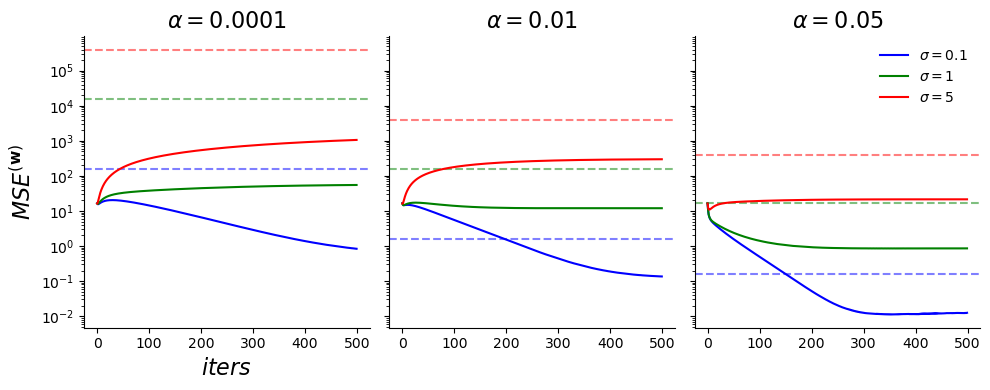

In [39]:
labels = [r'$\sigma = 0.1$', r'$\sigma = 1$', r'$\sigma = 5$']
titles = [r'$\alpha=0.0001$', r'$\alpha=0.01$', r'$\alpha=0.1$']
cs = ['b', 'g', 'r', 'c', 'm']

fig, axs = plt.subplots(1, len(reg), sharey=True, figsize=(10,4))

for ax, w_tilde_, bound_, title in zip(axs, w_tilde, bound, titles):
    for i in range(len(noise_vals)):
        ax.plot(np.arange(len(w_tilde_[i])), w_tilde_[i], label=labels[i], c=cs[i])
        ax.axhline(y= bound_[i],ls='--', c=cs[i], alpha=0.5)
    ax.set_title(title)

axs[0].set_ylabel (r'$MSE^{(\mathbf{w})}$')
axs[0].set_xlabel ('$iters$')

plt.legend(frameon=False)
plt.yscale('log')
#fig.suptitle('FedRelax weight vector MSE w.r.t. noise level, d/m=1')
fig.tight_layout()
#plt.savefig("Pytorch_clustered_w_err_noise.png")
plt.show()

In [21]:
%%time

p_out = 0.2
n_features = 5
reg        = [0.0001, 0.01, 0.1]
p_in_vals  = [0.2, 0.6, 1]
noise = 0.1
iters = 500

#if save_npy:
err            = np.zeros((len(reg),len(noise_vals), iters))
w_tilde        = np.zeros((len(reg),len(noise_vals), iters))
bound          = np.zeros((len(reg),len(noise_vals)))

for i, reg_term in enumerate(reg):  
    out = Parallel(n_jobs=-1)(delayed(experiment)(p_in, p_out, reg_term, n_features, noise, iters) for p_in in p_in_vals)

    
    for j in range(len(noise_vals)):
        w_tilde[i,j]   = out[j][0]
        err[i,j]        = out[j][1]
        bound[i,j]      = out[j][2]

CPU times: user 185 ms, sys: 258 ms, total: 443 ms
Wall time: 9min 46s


In [37]:
# save for tikz plotting in csv format

df = pd.DataFrame(data=w_tilde.reshape(-1,iters).T)
df.to_csv('FedRelax_w_tilde_pin.csv', mode='a', index=True, header=None)

df = pd.DataFrame(data=np.repeat(bound.reshape(3,3,1), iters, axis=-1).reshape(-1,iters).T)
df.to_csv('FedRelax_bound_pin.csv', mode='a', index=True, header=None)

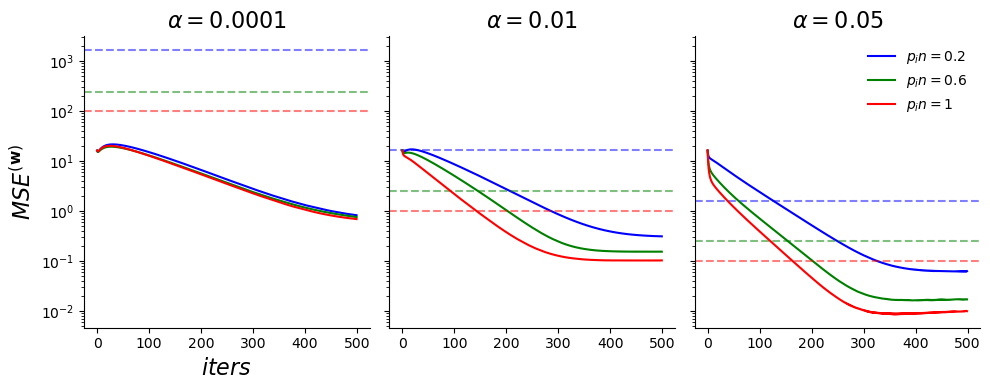

In [22]:
labels = [r'$p_in = 0.2$', r'$p_in = 0.6$', r'$p_in = 1$']
titles = [r'$\alpha=0.0001$', r'$\alpha=0.01$', r'$\alpha=0.1$']
cs = ['b', 'g', 'r', 'c', 'm']

fig, axs = plt.subplots(1, len(reg), sharey=True, figsize=(10,4))

for ax, w_tilde_, bound_, title in zip(axs, w_tilde, bound, titles):
    for i in range(len(noise_vals)):
        ax.plot(np.arange(len(w_tilde_[i])), w_tilde_[i], label=labels[i], c=cs[i])
        ax.axhline(y= bound_[i],ls='--', c=cs[i], alpha=0.5)
    ax.set_title(title)

axs[0].set_ylabel (r'$MSE^{(\mathbf{w})}$')
axs[0].set_xlabel ('$iters$')

plt.legend(frameon=False)
plt.yscale('log')
#fig.suptitle('FedRelax weight vector MSE w.r.t. noise level, d/m=1')
fig.tight_layout()
#plt.savefig("Pytorch_clustered_w_err_noise.png")
plt.show()